# Building a Simple Neural Network

Step 1: Load the data and Preprocess Data

In [ ]:
# Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load data
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Reshape data toinclude the channel dimension (28, 28, 1) for grayscaleimages
# Normalize pixel values to between 0 and 1 -> for computational efficiency and faster convergence
X_train = X_train.reshape((60000, 28, 28, 1)).astype('float32') / 255
X_test = X_test.reshape((10000, 28, 28, 1)).astype('float32') / 255 


print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

I0000 00:00:1790255174.704897  163520 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790255175.741685  163520 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790255182.838407  163520 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


Step 2: Build the CNN architecture

In [2]:
# Initialize a sequential model
model = models.Sequential()

# -----Feature Extraction Block-----
# First Convolutional Layer: learns 32 distinct 3x3 spatial filters
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

# Max Pooling Layer: reduces spatial dimensions by taking the maximum value in each 2x2 window
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))


#-------Calssification Block-------
# Flatten the 2D feature maps into a 1D vector to feed into the fully connected layers
model.add(layers.Flatten())

# Fully connected layer for learning complex patterns and relationships in the data
model.add(layers.Dense(64, activation='relu'))

# Output layer with 10 neurons (one for each digit class) and softmax activation for multi-class classification
model.add(layers.Dense(10, activation='softmax'))

model.summary()  # Display the model architecture


/home/ch4mp/OneDrive/Desktop/DSA Projects/Deep Learning/.venv/lib64/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1790255554.863713  163520 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609,354 (2.32 MB)

 Trainable params: 609,354 (2.32 MB)

 Non-trainable params: 0 (0.00 B)

Step 3: Compile the model
- Define how the model learns by setting up the optimizer, loss function, and metrics.. Then, run the training pipeline for 3 epochs. The model will learn to classify the images in the training set and validate its performance on the validation set.

In [3]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=3, 
                    validation_data=(X_test, y_test),
                    batch_size=64)

Epoch 1/3


W0000 00:00:1790255889.242237  163520 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


938/938 ━━━━━━━━━━━━━━━━━━━━ 124s 128ms/step - accuracy: 0.9574 - loss: 0.1410 - val_accuracy: 0.9818 - val_loss: 0.0587
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 119s 127ms/step - accuracy: 0.9866 - loss: 0.0452 - val_accuracy: 0.9893 - val_loss: 0.0339
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 128s 137ms/step - accuracy: 0.9916 - loss: 0.0292 - val_accuracy: 0.9850 - val_loss: 0.0450


Step 4: Visualize Training History & Predictions

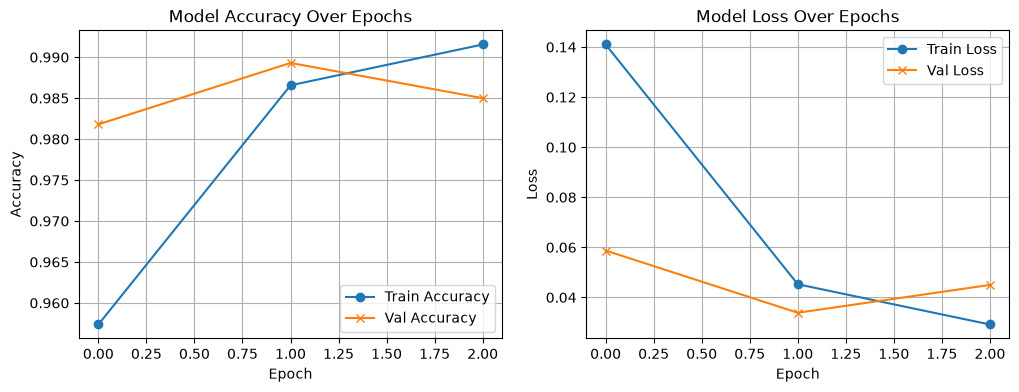

In [5]:
# Plot Loass and accuracy curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


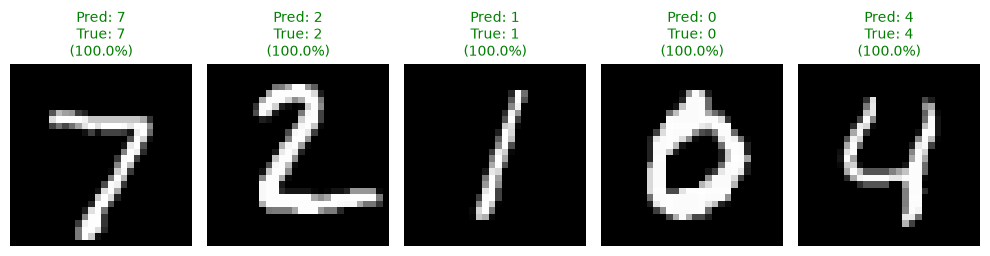

In [ ]:
# Visualizing Model Predictions
import numpy as np
import matplotlib.pyplot as plt # Added missing import

# Get predictions for the first 5 test images
predictions = model.predict(X_test[:5])
plt.figure(figsize=(10, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    
    # INDENTED: Everything below must run for each image in the loop
    # Reshape back to 28x28 for plotting
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    
    # Find the class with the highest probability
    pred_label = np.argmax(predictions[i])
    confidence = np.max(predictions[i]) * 100
    
    # Handle both scalar and array formats for y_test
    # If y_test is one-hot encoded, you might need np.argmax(y_test[i]) instead
    true_label = y_test[i] 
    
    # Title turns green if correct, red if incorrect
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}\n({confidence:.1f}%)", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

Evaluate and Predict

In [10]:
# 1. Evaluate accuracy on the test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n Test Accuracy: {test_acc * 100:.2f}%")


# 2. Make a single prediction
sample_image = X_test[0].reshape(1, 28, 28, 1)
prediction = model.predict(sample_image)
predicted_label = prediction.argmax()

print(f"Predicted Class: {predicted_label} | True Class: {y_test[0]}")


 Test Accuracy: 98.50%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
Predicted Class: 7 | True Class: 7
